In [1]:
import sys
import os

sys.path.append(os.path.abspath(".."))

In [2]:
from src.preprocessing import load_data
from src.preprocessing import encode_features
from src.preprocessing import split_features

In [3]:
train_data = load_data("../data/raw/KDDTrain+.txt")
test_data  = load_data("../data/raw/KDDTest+.txt")
train_data = encode_features(train_data)
test_data  = encode_features(test_data)

X_train, y_train = split_features(train_data)
X_test,  y_test  = split_features(test_data)

In [4]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

x_train = scaler.fit_transform(X_train)
x_test  = scaler.transform(X_test)

In [5]:
from src.isolation_forest_model import train_isolation_forest

model = train_isolation_forest(x_train)

In [6]:
from src.isolation_forest_model import detect_anomalies

predictions = detect_anomalies(model,x_test)

In [7]:
import numpy as np

np.unique(predictions, return_counts = True)

(array([-1,  1]), array([12658,  9886]))

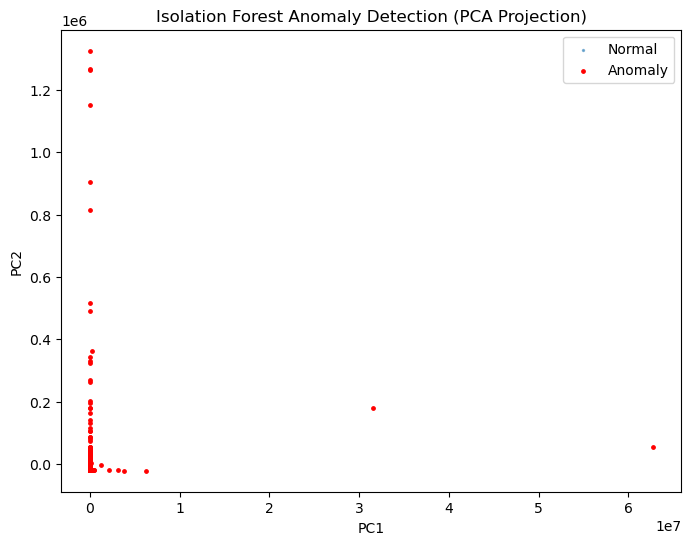

In [8]:
import matplotlib.pyplot as plt

from sklearn.decomposition import PCA

pca = PCA(n_components=2)

pca = PCA(n_components=2)
x_train_pca = pca.fit_transform(X_train)
x_test_pca = pca.transform(X_test)

normal = x_test_pca[predictions == 1]
anomaly = x_test_pca[predictions == -1]

plt.figure(figsize=(8,6))

plt.scatter(normal[:,0], normal[:,1], s=2, label="Normal", alpha=0.5)
plt.scatter(anomaly[:,0], anomaly[:,1], s=6, color="red", label="Anomaly")

plt.title("Isolation Forest Anomaly Detection (PCA Projection)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend()

plt.show()

In [9]:
# The first two principal components capture ~61% of the variance.
# While sufficient for visualization, some overlap occurs due to the
# high dimensional nature of the NSL-KDD dataset.

In [10]:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

attack_test = (y_test != "normal").astype(int)

pred = (predictions == -1).astype(int)

cm = confusion_matrix(attack_test, pred)
print(cm)

print(classification_report(attack_test, pred))

[[ 7452  2259]
 [ 2434 10399]]
              precision    recall  f1-score   support

           0       0.75      0.77      0.76      9711
           1       0.82      0.81      0.82     12833

    accuracy                           0.79     22544
   macro avg       0.79      0.79      0.79     22544
weighted avg       0.79      0.79      0.79     22544



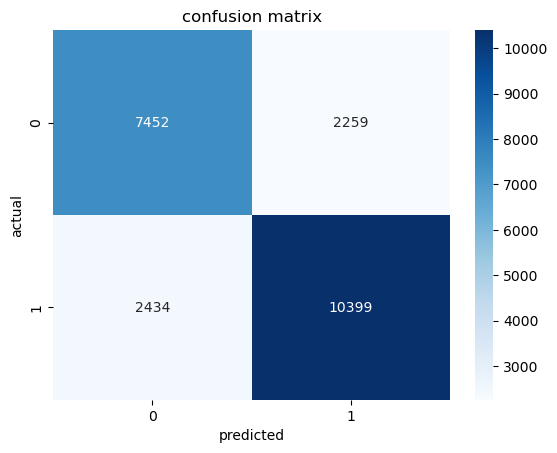

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(cm, annot = True, fmt = 'd', cmap = "Blues")
plt.title("confusion matrix")
plt.xlabel("predicted")
plt.ylabel("actual")

plt.show()

In [12]:
import joblib

joblib.dump(model, "../results/isolation_forest_model.pkl")

['../results/isolation_forest_model.pkl']

In [13]:
# Isolation Forest assumes anomalies are rare events.
# However, in the NSL-KDD dataset attacks constitute nearly half of the traffic.
# Therefore the algorithm struggles to identify many attack instances.

In [14]:
from src.dbscan_model import train_dbscan

dbscan_labels = train_dbscan(x_train)

In [15]:
from sklearn.cluster import DBSCAN

dbscan_test = DBSCAN(eps=0.8, min_samples=10).fit(x_test)
dbscan_labels = dbscan_test.labels_

pred_dbscan = (dbscan_labels == -1).astype(int)

attack_test = (y_test != "normal").astype(int)

from sklearn.metrics import classification_report
print(classification_report(attack_test, pred_dbscan))

              precision    recall  f1-score   support

           0       0.44      0.93      0.60      9711
           1       0.67      0.11      0.18     12833

    accuracy                           0.46     22544
   macro avg       0.56      0.52      0.39     22544
weighted avg       0.57      0.46      0.36     22544



In [16]:
# DBSCAN performs poorly on the NSL-KDD dataset due to the high
# dimensionality of the feature space. Density-based clustering
# methods rely on meaningful distance metrics, which degrade in
# high-dimensional environments. As a result, most data points are
# assigned to clusters and very few are labeled as noise (anomalies).

In [17]:
# Isolation Forest performs significantly better than DBSCAN on the NSL-KDD dataset
# because tree-based isolation methods handle high-dimensional data more effectively
# than density-based clustering algorithms.

<Figure size 800x600 with 0 Axes>

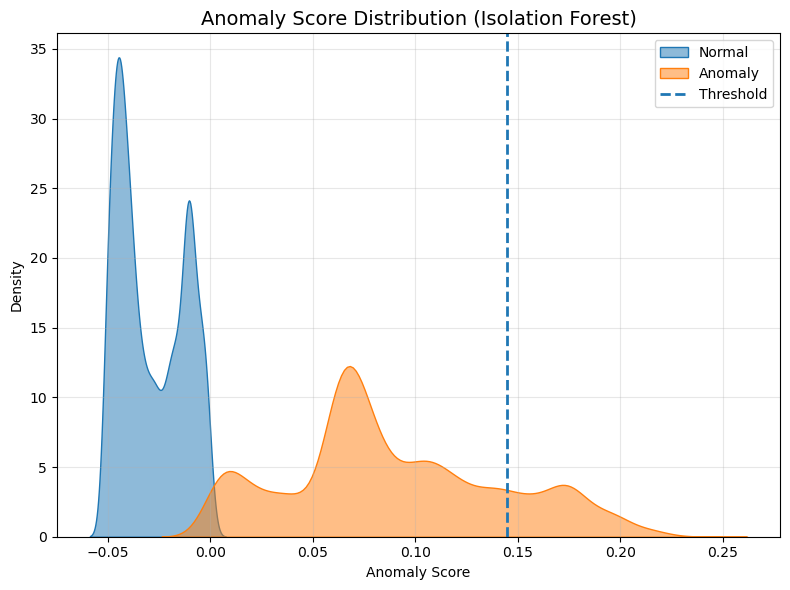

In [26]:
import numpy as np
import matplotlib.pyplot as plt

# ✅ Always use SAME data type (numpy)
X_test_np = X_test.values

# Get anomaly scores (higher = normal → invert)
scores = model.decision_function(X_test_np)
anomaly_score = -scores

test_data["anomaly_score"] = anomaly_score

# Predictions
pred = model.predict(X_test_np)
test_data["anomaly"] = (pred == -1).astype(int)

# Threshold (clean + stable)
threshold = np.percentile(anomaly_score, 90)

# -------------------- PLOT --------------------
plt.figure(figsize=(8,6))

# Normal vs Anomaly separation
normal_scores = anomaly_score[test_data["anomaly"] == 0]
anomaly_scores = anomaly_score[test_data["anomaly"] == 1]

import seaborn as sns

plt.figure(figsize=(8,6))

sns.kdeplot(normal_scores, label="Normal", fill=True, alpha=0.5)
sns.kdeplot(anomaly_scores, label="Anomaly", fill=True, alpha=0.5)

plt.axvline(threshold, linestyle="--", linewidth=2, label="Threshold")

plt.title("Anomaly Score Distribution (Isolation Forest)", fontsize=14)
plt.xlabel("Anomaly Score")
plt.ylabel("Density")

plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("../results/anomaly_score_density.png", dpi=300)
plt.show()

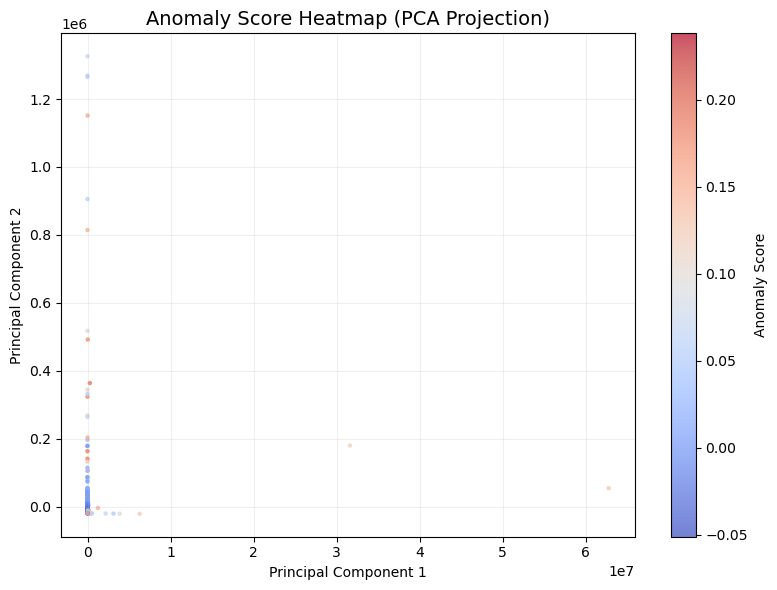

In [54]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

x_train_pca = pca.fit_transform(X_train)
x_test_pca = pca.transform(X_test)



plt.figure(figsize=(8,6))

scatter = plt.scatter(
    x_test_pca[:,0],
    x_test_pca[:,1],
    c=test_data["anomaly_score"],
    cmap="coolwarm",
    s=5,
    alpha=0.7
)

cbar = plt.colorbar(scatter)
cbar.set_label("Anomaly Score")

plt.title("Anomaly Score Heatmap (PCA Projection)", fontsize=14)
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.grid(alpha=0.2)

plt.tight_layout()
plt.savefig("../results/anomaly_heatmap.png", dpi=300)
plt.show()

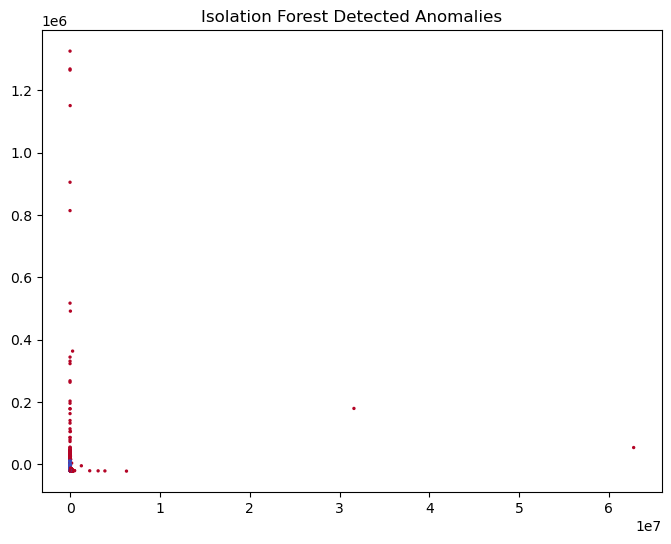

In [55]:
plt.figure(figsize=(8,6))

plt.scatter(
    x_pca[:,0],
    x_pca[:,1],
    c=test_data["anomaly"],
    cmap="coolwarm",
    s=2
)

plt.title("Isolation Forest Detected Anomalies")

plt.show()

In [29]:
test_data.sort_values("anomaly_score", ascending=False).head(10)

,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,label,anomaly_score,anomaly
11765,1776,1,55,9,3061,54942,0,0,0,15,...,0.44,0.11,1.00,0.00,0.00,0.00,0.00,multihop,0.238027,1
16011,8,1,43,2,0,36,0,0,0,0,...,0.80,0.20,0.05,0.00,0.02,0.40,0.97,mscan,0.236788,1
1003,0,1,45,10,0,0,0,0,0,0,...,1.00,1.00,0.00,1.00,1.00,0.00,0.00,nmap,0.228399,1
22095,0,1,55,2,0,0,0,0,0,0,...,0.75,0.89,0.67,0.02,0.00,0.87,0.33,portsweep,0.226718,1
868,0,1,52,1,0,0,0,0,0,0,...,0.09,0.02,0.04,0.04,0.00,0.88,1.00,mscan,0.225067,1
6376,1,1,55,2,0,15,0,0,0,0,...,0.12,0.02,0.02,0.05,0.02,0.85,0.67,mscan,0.223537,1
14504,4,1,55,9,24,1254,0,0,0,0,...,0.67,0.17,0.04,0.00,0.01,0.50,0.67,mscan,0.221569,1
21200,0,1,55,8,0,44,0,0,0,0,...,0.47,0.00,0.00,0.38,0.77,0.46,0.02,processtable,0.220998,1
9245,9,1,55,9,24,109,0,0,0,0,...,0.67,0.17,0.04,0.00,0.00,0.50,0.70,mscan,0.220794,1
9200,0,1,45,1,0,0,0,0,0,0,...,0.74,0.86,0.00,0.02,0.33,0.85,0.67,normal,0.220778,1


In [30]:
test_data["label"].value_counts().head(10)

label
normal          9711
neptune         4657
guess_passwd    1231
mscan            996
warezmaster      944
apache2          737
satan            735
processtable     685
smurf            665
back             359
Name: count, dtype: int64

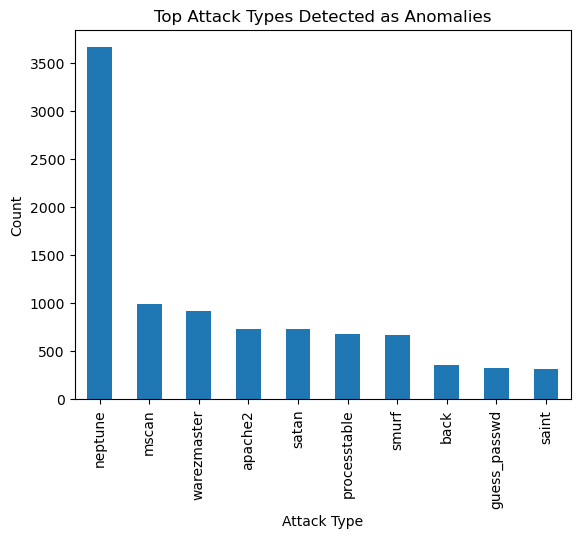

In [31]:
import matplotlib.pyplot as plt

# Only anomalies detected by model
detected_attacks = test_data[
    (test_data["anomaly"] == 1) & (test_data["label"] != "normal")
]["label"].value_counts().head(10)

detected_attacks.plot(kind="bar")

plt.title("Top Attack Types Detected as Anomalies")
plt.xlabel("Attack Type")
plt.ylabel("Count")

plt.show()

In [32]:
false_positives = test_data[
    (test_data["anomaly"] == 1) & (test_data["label"] == "normal")
]
print("False positive rate:",
      len(false_positives) / len(test_data[test_data["label"] == "normal"]))

False positive rate: 0.23262279888785914


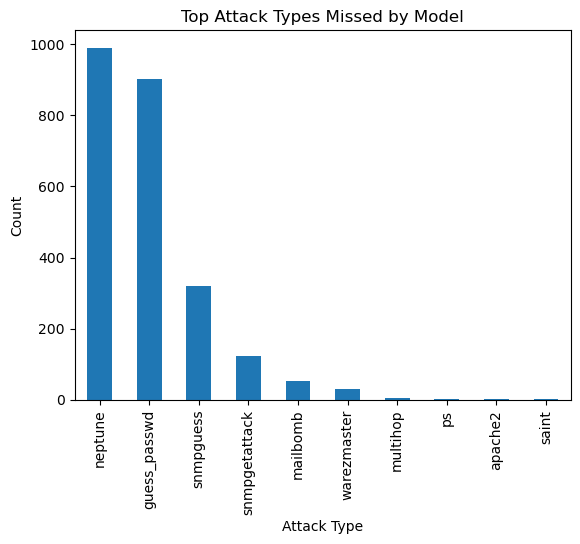

In [33]:
missed_attacks = test_data[
    (test_data["anomaly"] == 0) & (test_data["label"] != "normal")
]["label"].value_counts().head(10)

if len(missed_attacks) == 0:
    print("No missed attacks found")
else:
    missed_attacks.plot(kind="bar")
    plt.title("Top Attack Types Missed by Model")
    plt.xlabel("Attack Type")
    plt.ylabel("Count")
    plt.show()

In [34]:
anomalies = test_data[test_data['anomaly'] == 1]
anomalies['label'].value_counts().head(10)

label
neptune         3666
normal          2259
mscan            996
warezmaster      915
apache2          735
satan            735
processtable     685
smurf            665
back             359
guess_passwd     328
Name: count, dtype: int64

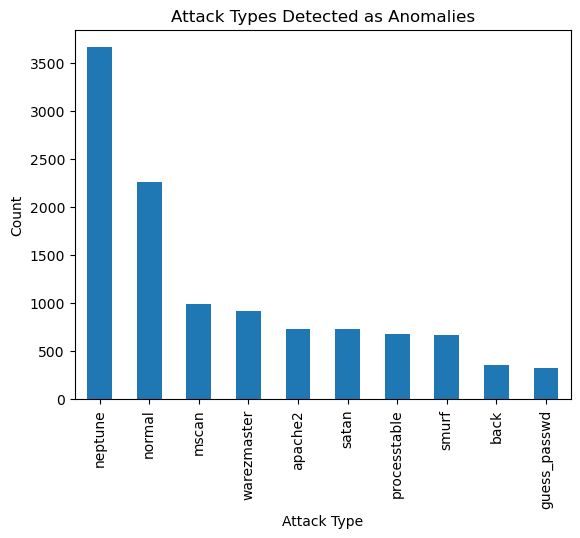

In [35]:
anomalies['label'].value_counts().head(10).plot(kind='bar')

plt.title("Attack Types Detected as Anomalies")
plt.xlabel("Attack Type")
plt.ylabel("Count")

plt.show()

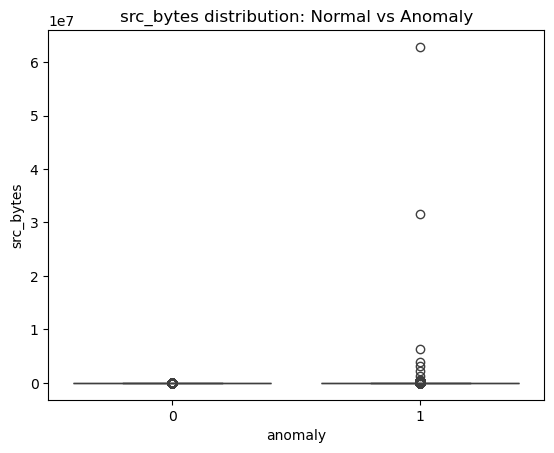

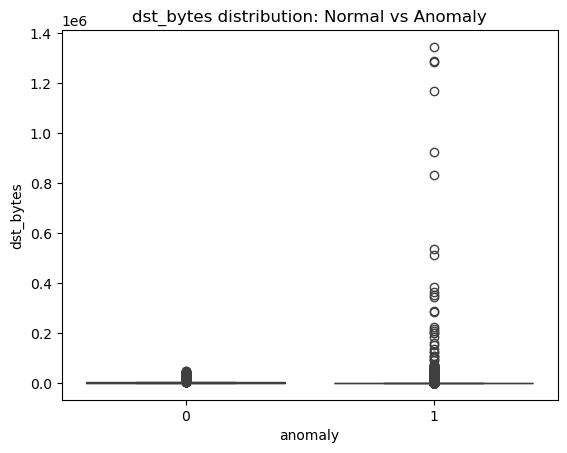

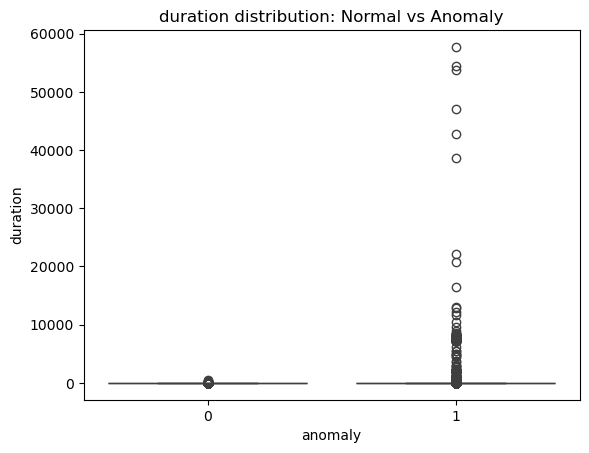

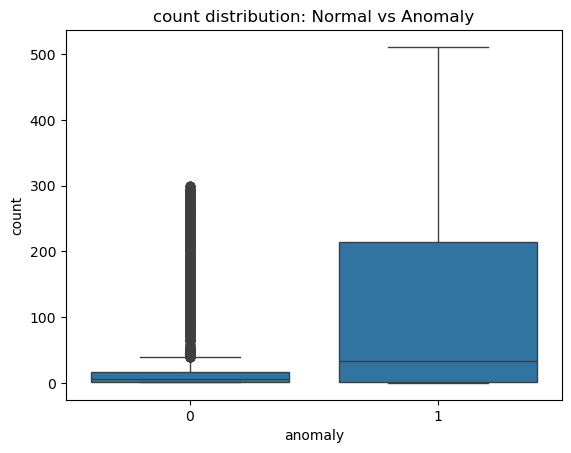

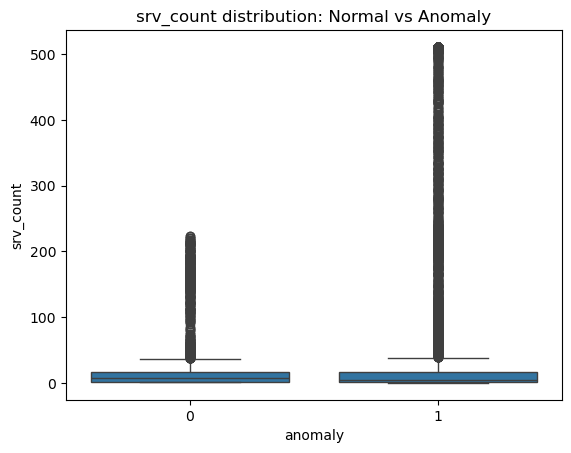

In [36]:
import seaborn as sns

features = ["src_bytes", "dst_bytes", "duration", "count", "srv_count"]

for feature in features:
    sns.boxplot(x=test_data["anomaly"], y=test_data[feature])
    plt.title(f"{feature} distribution: Normal vs Anomaly")
    plt.show()

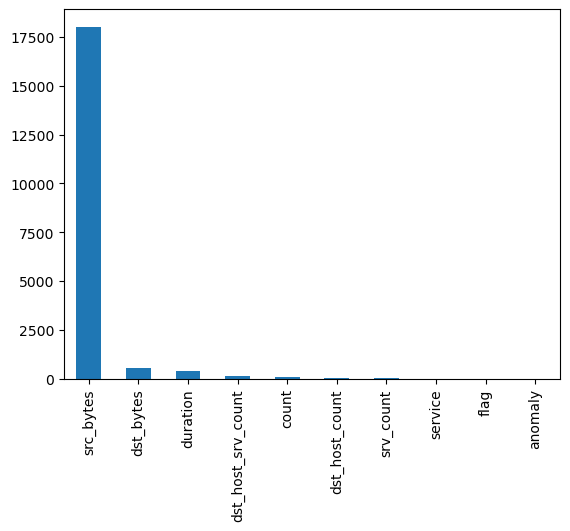

In [37]:
if test_data["anomaly"].nunique() < 2:
    print("Cannot compute feature differences (only one class present)")
else:
    numeric_data = test_data.select_dtypes(include=["int64", "float64"])

    normal = numeric_data[test_data["anomaly"] == 0]
    anomaly = numeric_data[test_data["anomaly"] == 1]

    diff = (anomaly.mean() - normal.mean()).abs().sort_values(ascending=False)
    diff.head(10).plot(kind='bar')

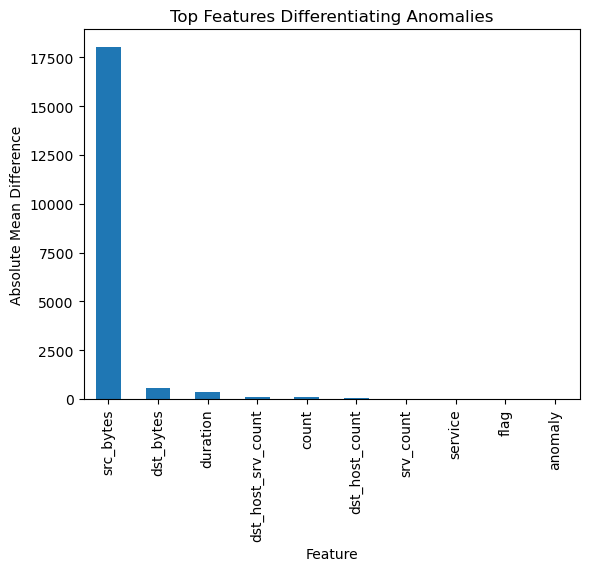

In [38]:
diff.head(10).plot(kind='bar')

plt.title("Top Features Differentiating Anomalies")
plt.ylabel("Absolute Mean Difference")
plt.xlabel("Feature")
plt.show()

In [39]:
test_data.sort_values("anomaly_score", ascending=False).head(10)

,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,label,anomaly_score,anomaly
11765,1776,1,55,9,3061,54942,0,0,0,15,...,0.44,0.11,1.00,0.00,0.00,0.00,0.00,multihop,0.238027,1
16011,8,1,43,2,0,36,0,0,0,0,...,0.80,0.20,0.05,0.00,0.02,0.40,0.97,mscan,0.236788,1
1003,0,1,45,10,0,0,0,0,0,0,...,1.00,1.00,0.00,1.00,1.00,0.00,0.00,nmap,0.228399,1
22095,0,1,55,2,0,0,0,0,0,0,...,0.75,0.89,0.67,0.02,0.00,0.87,0.33,portsweep,0.226718,1
868,0,1,52,1,0,0,0,0,0,0,...,0.09,0.02,0.04,0.04,0.00,0.88,1.00,mscan,0.225067,1
6376,1,1,55,2,0,15,0,0,0,0,...,0.12,0.02,0.02,0.05,0.02,0.85,0.67,mscan,0.223537,1
14504,4,1,55,9,24,1254,0,0,0,0,...,0.67,0.17,0.04,0.00,0.01,0.50,0.67,mscan,0.221569,1
21200,0,1,55,8,0,44,0,0,0,0,...,0.47,0.00,0.00,0.38,0.77,0.46,0.02,processtable,0.220998,1
9245,9,1,55,9,24,109,0,0,0,0,...,0.67,0.17,0.04,0.00,0.00,0.50,0.70,mscan,0.220794,1
9200,0,1,45,1,0,0,0,0,0,0,...,0.74,0.86,0.00,0.02,0.33,0.85,0.67,normal,0.220778,1


In [40]:
print("Total attacks:", sum(test_data["label"] != "normal"))
print("Detected attacks:", sum((test_data["anomaly"] == 1) & (test_data["label"] != "normal")))
print("Missed attacks:", sum((test_data["anomaly"] == 0) & (test_data["label"] != "normal")))

Total attacks: 12833
Detected attacks: 10399
Missed attacks: 2434


In [41]:
print(test_data["anomaly"].value_counts())

anomaly
1    12658
0     9886
Name: count, dtype: int64


In [42]:
# DBSCAN failed completely on NSL-KDD due to high dimensionality.
# It labeled all points as anomalies, making it unsuitable for this dataset.

In [43]:
# DBSCAN struggles with high-dimensional data like NSL-KDD.
# Distance metrics become less meaningful, causing poor clustering.
# As a result, many normal points are incorrectly flagged as anomalies,
# leading to high false positives and low overall accuracy.

In [44]:
### Final Observations

# - Isolation Forest performs well on high-dimensional data
# - Detects majority of attack types with good balance
# - Produces some false positives due to assumption of anomaly rarity

# - DBSCAN fails to model the dataset effectively
# - High dimensionality reduces clustering effectiveness
# - Leads to poor precision and unstable performance

# Conclusion:
# Tree-based anomaly detection methods are more suitable
# for network intrusion datasets than density-based methods.